In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
df=sns.load_dataset("titanic")

In [3]:
df.to_csv("titanic.csv",index=False)

In [4]:
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.shape

(891, 15)

## Handle Missing Values

In [8]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage = missing_percentage[missing_percentage>0]

print("Missing Percentage %: \n")
print(missing_percentage)

Missing Percentage %: 

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [9]:
# Drop rows with very small amounts of missing data
df = df.dropna(subset=["embarked", "embark_town"])

# Impute age using the median
df["age"] = df["age"].fillna(df["age"].median())

# Drop deck because of very high missingness
df = df.drop(columns=["deck"])

In [10]:
print("Shape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nDescribe:")
print(df.describe())

Shape:
(889, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        889 non-null    object  
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 86.1+ KB

Describe:
         survived      pclass         age       sibsp       parch        fare
count  889.000

# Outliers

In [11]:
# Function to calculate IQR outliers
def count_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    return len(outliers), lower_bound, upper_bound


age_outliers, age_lower, age_upper = count_iqr_outliers(df["age"])
fare_outliers, fare_lower, fare_upper = count_iqr_outliers(df["fare"])

print("Age")
print("Outliers:", age_outliers)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)

print("\nFare")
print("Outliers:", fare_outliers)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)

Age
Outliers: 65
Lower bound: 2.5
Upper bound: 54.5

Fare
Outliers: 114
Lower bound: -26.7605
Upper bound: 65.6563


In [12]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


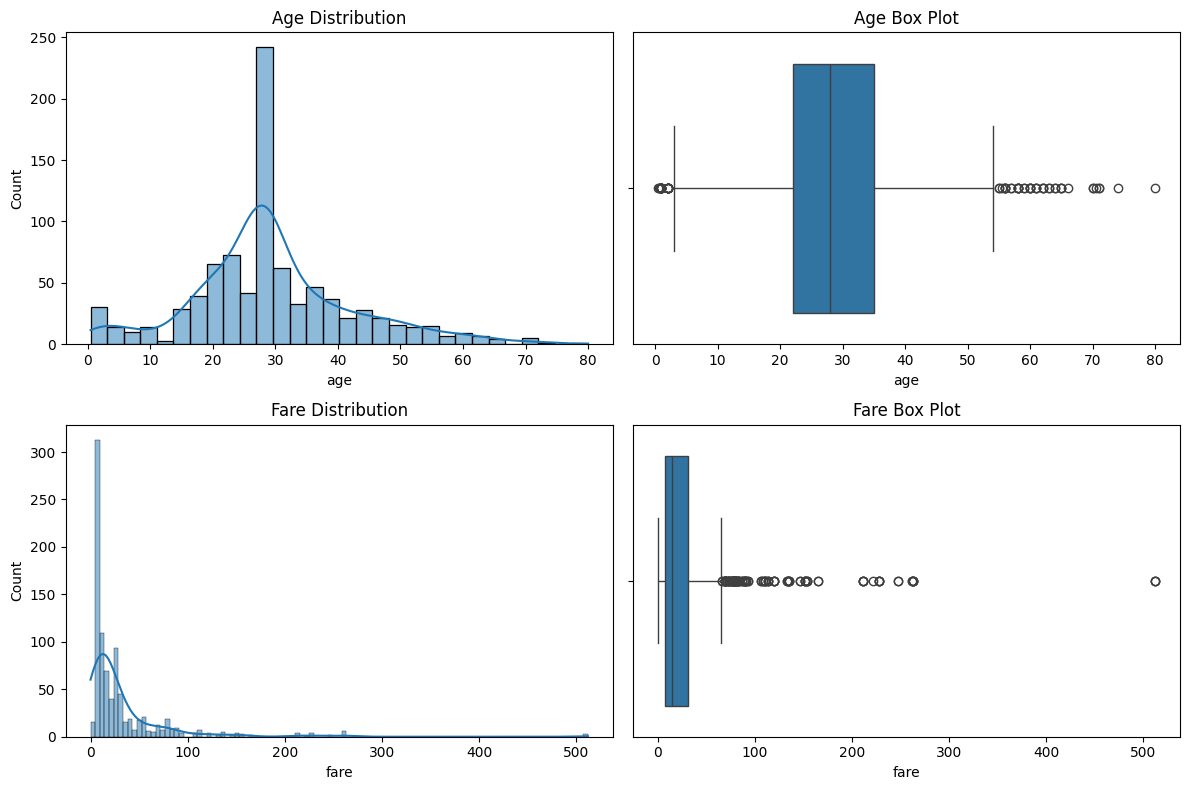

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

sns.boxplot(x=df["age"], ax=axes[0, 1])
axes[0, 1].set_title("Age Box Plot")

sns.histplot(df["fare"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Fare Distribution")

sns.boxplot(x=df["fare"], ax=axes[1, 1])
axes[1, 1].set_title("Fare Box Plot")

plt.tight_layout()
plt.show()

### Fare Distribution Interpretation

The fare distribution is right-skewed because the mean fare (32.10) is greater than the median (14.45), which is greater than the mode (8.05). This indicates that a relatively small number of passengers paid substantially higher fares, pulling the mean toward the upper end of the distribution. The IQR rule identifies 114 fare observations as outliers.

### Age Outlier Interpretation

Using the IQR rule, the lower bound for age is 2.5 years and the upper bound is 54.5 years. There are 65 observations outside these bounds, so these observations are classified as age outliers according to the IQR method.

## Bivariate analysis

In [14]:
male_survival = df[df["sex"] == "male"]["survived"].mean()
female_survival = df[df["sex"] == "female"]["survived"].mean()

print("Male survival rate:", male_survival)
print("Female survival rate:", female_survival)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154


In [15]:
class_1_survival = df[df["pclass"] == 1]["survived"].mean()
class_2_survival = df[df["pclass"] == 2]["survived"].mean()
class_3_survival = df[df["pclass"] == 3]["survived"].mean()

print("1st class survival rate:", class_1_survival)
print("2nd class survival rate:", class_2_survival)
print("3rd class survival rate:", class_3_survival)

1st class survival rate: 0.6261682242990654
2nd class survival rate: 0.47282608695652173
3rd class survival rate: 0.24236252545824846


In [16]:
female_first = df[
    (df["sex"] == "female") & (df["pclass"] == 1)
]["survived"].mean()

female_second = df[
    (df["sex"] == "female") & (df["pclass"] == 2)
]["survived"].mean()

female_third = df[
    (df["sex"] == "female") & (df["pclass"] == 3)
]["survived"].mean()

male_first = df[
    (df["sex"] == "male") & (df["pclass"] == 1)
]["survived"].mean()

male_second = df[
    (df["sex"] == "male") & (df["pclass"] == 2)
]["survived"].mean()

male_third = df[
    (df["sex"] == "male") & (df["pclass"] == 3)
]["survived"].mean()

In [17]:
print("Female, 1st class:", female_first)
print("Female, 2nd class:", female_second)
print("Female, 3rd class:", female_third)

print("Male, 1st class:", male_first)
print("Male, 2nd class:", male_second)
print("Male, 3rd class:", male_third)

Female, 1st class: 0.967391304347826
Female, 2nd class: 0.9210526315789473
Female, 3rd class: 0.5
Male, 1st class: 0.36885245901639346
Male, 2nd class: 0.1574074074074074
Male, 3rd class: 0.13544668587896252


In [18]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


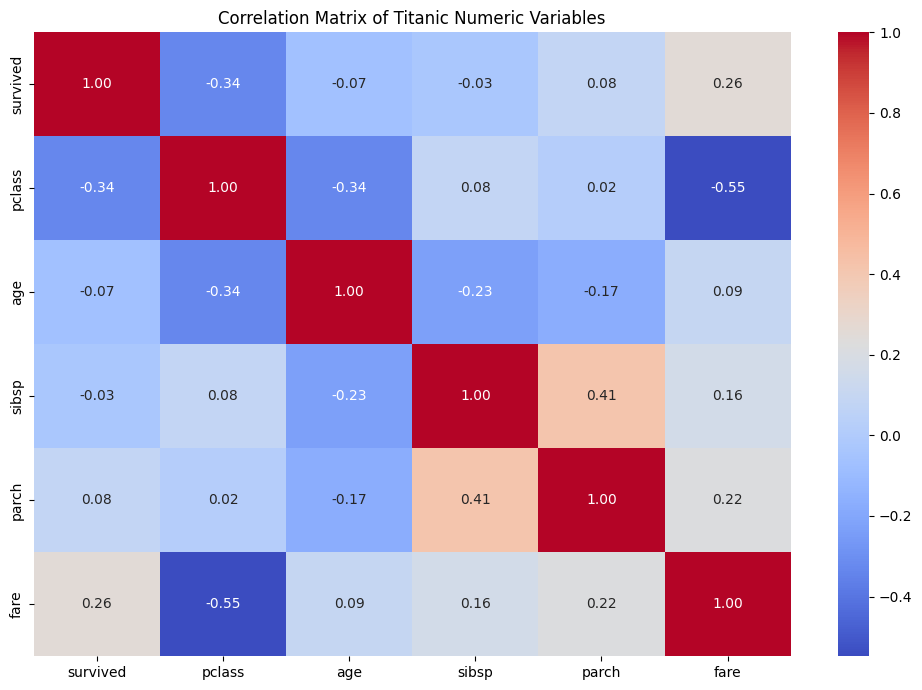

In [19]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Titanic Numeric Variables")
plt.tight_layout()
plt.show()

In [20]:
# Get the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
    ~__import__("numpy").tril(
        __import__("numpy").ones(corr_matrix.shape),
        k=0
    ).astype(bool)
)

# Convert correlations into pairs
correlation_pairs = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Strongest correlations:")
print(correlation_pairs.head(2))

Strongest correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


In [21]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Top 2 strongest correlations:")
print(correlation_pairs.head(2))

Top 2 strongest correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


In [22]:
print(corr_matrix)
print(correlation_pairs.head(2))

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


### Strongest Correlations

The strongest correlation is between `pclass` and `fare`, with a correlation coefficient of -0.548. This moderate negative relationship indicates that higher passenger-class numbers (where 3 represents third class) tend to be associated with lower fares.

The second strongest correlation is between `sibsp` and `parch`, with a correlation coefficient of 0.415. This positive relationship indicates that passengers travelling with more siblings/spouses tended to also have more parents/children recorded in the dataset.

## Multivariate data story

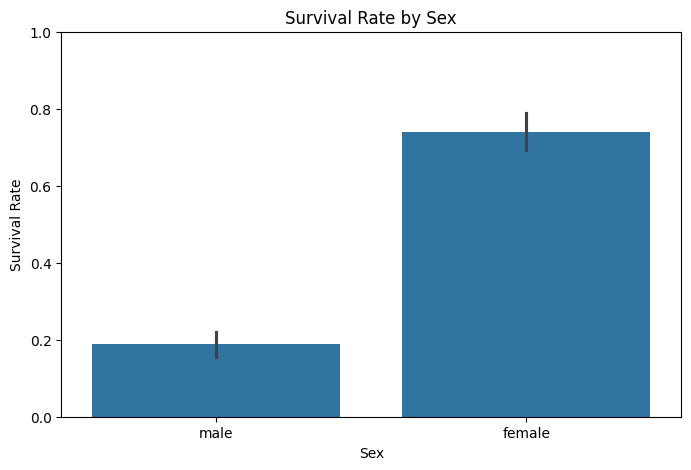

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.ylim(0, 1)

plt.show()

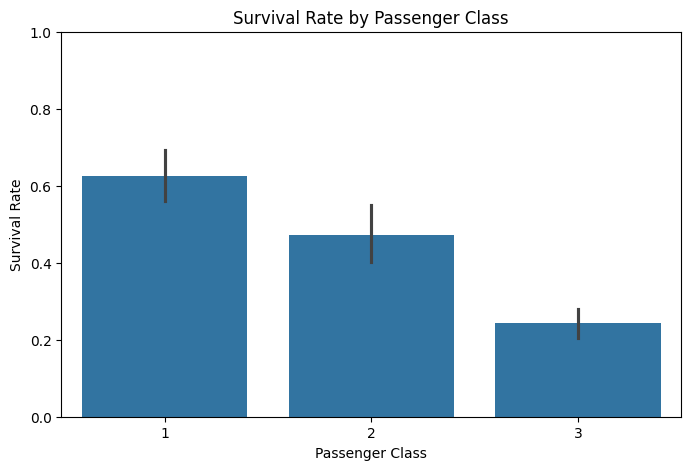

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)

plt.show()

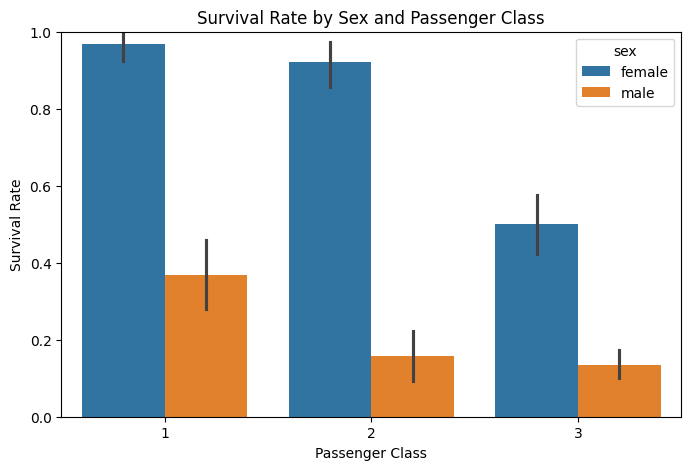

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)

plt.show()

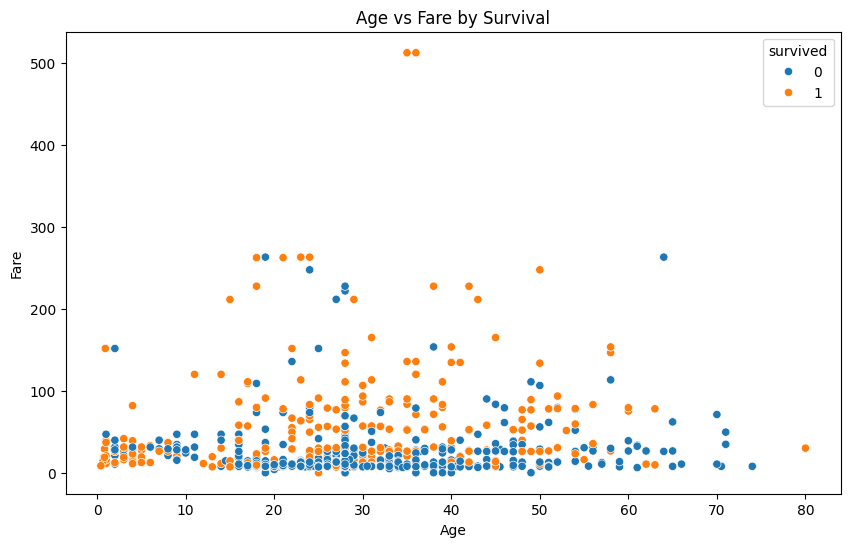

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

# Multivariate Data Story

## Chart 1 — Survival Rate by Sex

The survival rate differs substantially between the two sexes in this dataset. The survival rate for female passengers was approximately **74.04%**, compared with approximately **18.89%** for male passengers. This shows a large descriptive difference in survival outcomes by sex.

---

## Chart 2 — Survival Rate by Passenger Class

Survival rates differ across passenger classes. The observed survival rates were approximately **62.62% for first class**, **47.28% for second class**, and **24.24% for third class**. This indicates a substantial association between passenger class and survival in this dataset.

---

## Chart 3 — Survival Rate by Sex and Passenger Class

Survival rates vary across both sex and passenger class. Female survival was approximately **96.74% in first class**, **92.11% in second class**, and **50.00% in third class**, while male survival was approximately **36.89%**, **15.74%**, and **13.54%**, respectively. The combined breakdown shows that considering sex and passenger class together provides more detail than examining either variable independently.

---

## Chart 4 — Age vs Fare by Survival

The scatter plot shows the relationship between passenger age and fare while distinguishing passengers by survival outcome. Fare values are concentrated at lower levels for many passengers, while a smaller number of passengers paid substantially higher fares. The plot provides a multivariate view of how age and fare vary across survival outcomes, complementing the separate survival-rate analyses.

---

In [27]:
scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[["age", "fare"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

In [28]:
df_standardized

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,-0.563674,1,0,-0.500240,S,Third,man,True,Southampton,no,False
1,1,1,female,0.669217,1,0,0.788947,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,-0.255451,0,0,-0.486650,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.438050,1,0,0.422861,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.438050,0,0,-0.484133,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,-0.178396,0,0,-0.384475,S,Second,man,True,Southampton,no,True
887,1,1,female,-0.794841,0,0,-0.042213,S,First,woman,False,Southampton,yes,True
888,0,3,female,-0.101340,1,2,-0.174084,S,Third,woman,False,Southampton,no,False
889,1,1,male,-0.255451,0,0,-0.042213,C,First,man,True,Cherbourg,yes,True


In [29]:
print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter standardization:")
print(df_standardized[["age", "fare"]].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


In [30]:
print("\nExact verification:")
print("Age mean:", df_standardized["age"].mean())
print("Age std:", df_standardized["age"].std(ddof=0))

print("Fare mean:", df_standardized["fare"].mean())
print("Fare std:", df_standardized["fare"].std(ddof=0))


Exact verification:
Age mean: 2.717486278497571e-16
Age std: 0.9999999999999999
Fare mean: 1.3987061727561027e-16
Fare std: 1.0


# Train/Test Split

In [31]:
print(df["survived"].value_counts())
print("\nClass proportions:")
print(df["survived"].value_counts(normalize=True))

survived
0    549
1    340
Name: count, dtype: int64

Class proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [32]:
X = df.drop(columns=["survived"])
y = df["survived"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))

Training shape: (711, 13)
Testing shape: (178, 13)

Training class proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class proportions:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [35]:
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [37]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# LogisticRegression

In [39]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [40]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [41]:
y_pred_logistic = logistic_pipeline.predict(X_test)
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    roc_auc_score
)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("AUC      :", logistic_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression
-------------------
Accuracy : 0.7808988764044944
Precision: 0.7543859649122807
Recall   : 0.6323529411764706
F1 Score : 0.688
AUC      : 0.8264705882352942

Confusion Matrix:
[[96 14]
 [25 43]]


# Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [44]:
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [45]:
y_pred_tree = decision_tree_pipeline.predict(X_test)
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [46]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree")
print("------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)
print("AUC      :", tree_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree
------------
Accuracy : 0.8146067415730337
Precision: 0.7868852459016393
Recall   : 0.7058823529411765
F1 Score : 0.7441860465116279
AUC      : 0.8206550802139037

Confusion Matrix:
[[97 13]
 [20 48]]


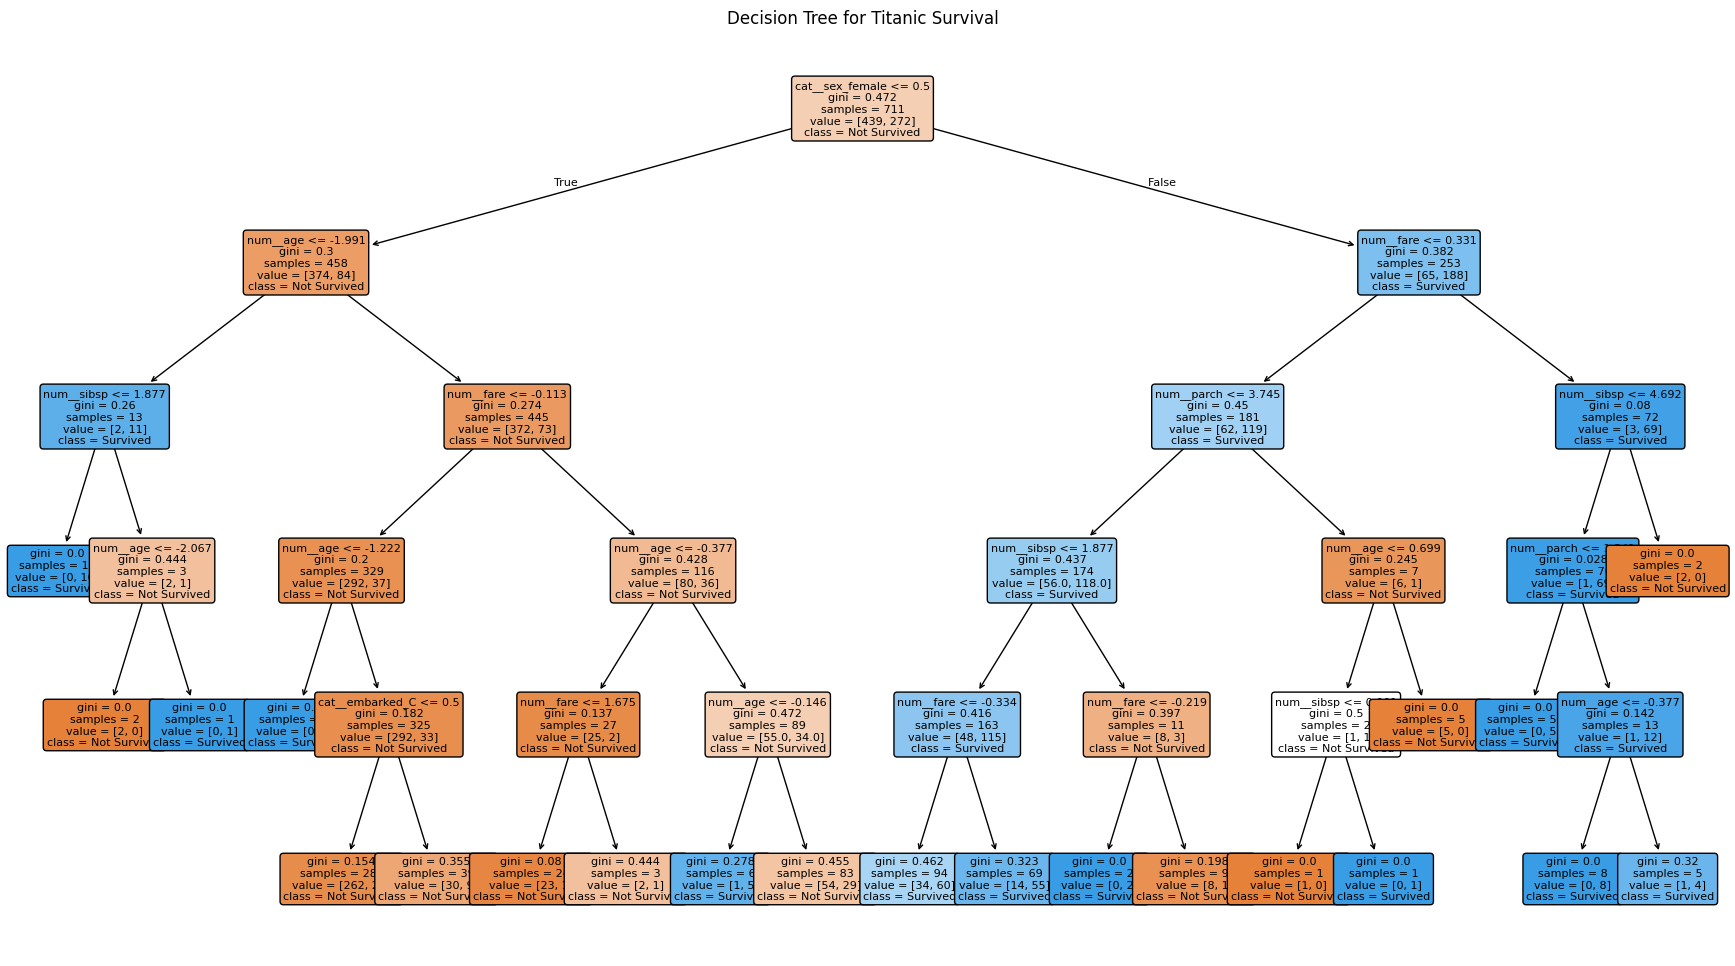

In [47]:
from sklearn.tree import plot_tree

fitted_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
fitted_tree = decision_tree_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 12))

plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival")
plt.show()

# RandomForestClassifier

In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [49]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [50]:
y_pred_rf = random_forest_pipeline.predict(X_test)
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [51]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("AUC      :", rf_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
-------------
Accuracy : 0.8202247191011236
Precision: 0.8103448275862069
Recall   : 0.6911764705882353
F1 Score : 0.746031746031746
AUC      : 0.8255347593582888

Confusion Matrix:
[[99 11]
 [21 47]]


In [52]:
rf_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
rf_model = random_forest_pipeline.named_steps["classifier"]

rf_feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=rf_feature_names
).sort_values(ascending=False)

print(feature_importance)

cat__sex_female    0.287977
cat__sex_male      0.268594
num__fare          0.190078
num__age           0.117330
num__sibsp         0.053348
num__parch         0.045281
cat__embarked_S    0.015380
cat__embarked_C    0.011933
cat__embarked_Q    0.010079
dtype: float64


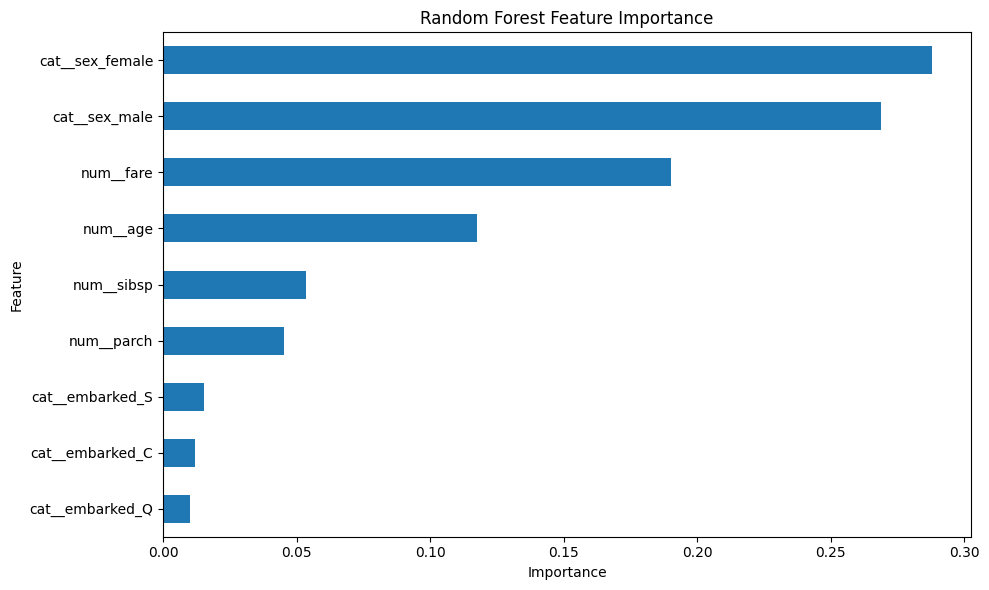

In [53]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [54]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

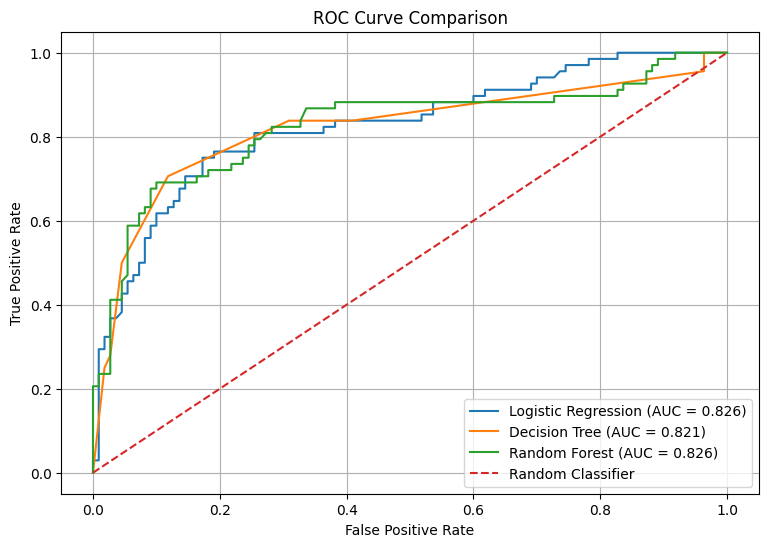

In [55]:
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    "F1": [
        logistic_f1,
        tree_f1,
        rf_f1
    ],
    "AUC": [
        logistic_auc,
        tree_auc,
        rf_auc
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.780899,0.754386,0.632353,0.688000,0.826471
1,Decision Tree,0.814607,0.786885,0.705882,0.744186,0.820655
2,Random Forest,0.820225,0.810345,0.691176,0.746032,0.825535


### Model Comparison

All three classifiers were evaluated using the same stratified train/test split and the same held-out test set. The models were compared using accuracy, precision, recall, F1 score, and ROC-AUC.

The Logistic Regression model achieved an accuracy of 0.781 and an AUC of 0.826. The Decision Tree achieved an accuracy of 0.815, an F1 score of 0.744, and an AUC of 0.821. The Random Forest achieved an accuracy of 0.820, precision of 0.810, F1 score of 0.746, and AUC of 0.826.

The metrics show that the models have different performance profiles. Accuracy, precision, recall, F1 score, and AUC should therefore be considered together rather than relying on a single metric.

In [57]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression:")
print(cm_logistic)

print("\nDecision Tree:")
print(cm_tree)

print("\nRandom Forest:")
print(cm_rf)

Logistic Regression:
[[96 14]
 [25 43]]

Decision Tree:
[[97 13]
 [20 48]]

Random Forest:
[[99 11]
 [21 47]]


In [58]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

print("\nDecision Tree")
print(classification_report(y_test, y_pred_tree))

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.75      0.63      0.69        68

    accuracy                           0.78       178
   macro avg       0.77      0.75      0.76       178
weighted avg       0.78      0.78      0.78       178


Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.74        68

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.69      0.75        68

    accuracy                           0.82       178
   macro avg       0.82      0.80      0.80       178
weighted avg       0.82 

In [59]:
import joblib

joblib.dump(
    random_forest_pipeline,
    "best_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [60]:
loaded_model = joblib.load("best_model.joblib")

print("Model loaded successfully.")

Model loaded successfully.


In [61]:
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [62]:
sample_passenger = pd.DataFrame({
    "pclass": [1],
    "sex": ["female"],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [80],
    "embarked": ["C"]
})

In [63]:
prediction = loaded_model.predict(sample_passenger)
probability = loaded_model.predict_proba(sample_passenger)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

if prediction[0] == 1:
    print("Predicted outcome: Survived")
else:
    print("Predicted outcome: Did not survive")

Prediction: 1
Probability: [0.03483235 0.96516765]
Predicted outcome: Survived


In [64]:
print("Sample input columns:")
print(sample_passenger.columns.tolist())

Sample input columns:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


### Saved Model and Raw-Input Verification

The complete Random Forest preprocessing and classification pipeline was saved as `best_model.joblib` using Joblib. The saved artifact contains both the `ColumnTransformer` preprocessing steps and the Random Forest estimator.

The saved pipeline was reloaded successfully and tested using a raw passenger record. No manual encoding, scaling, or imputation was applied to the sample before prediction. This verifies that the saved pipeline can perform the required preprocessing internally before generating a prediction.